# Importing Libraries

In [8]:
# Core Data Manipulation
import numpy as np
import pandas as pd

# Machine Learning & Clustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Data Visualization
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Geospatial Analysis
import geopandas as gpd
from keplergl import KeplerGl


# Loading DF

In [9]:
norm_df = pd.read_csv('..\\Data\\NMF_STREET.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\new-york-city-boroughs.geojson.txt")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# Clustering DBSCAN

In [10]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:", labels)
    print("===================")
    print("Value Counts:\n", labels.value_counts())


A rule proposed by the author of the algorithim is to set the min_samples to = num of dimension * 2 ( when our data is clean and has more than 1000 samples).

In [11]:
# Test run DBSCAN on random hyperparams
# Generate random values
eps_rnd = np.random.uniform(0.1,1)

# min_samples - points required to define a value as a core point
# eps - radious 
db = DBSCAN(eps = eps_rnd, min_samples = 18).fit(norm_df.drop("Street_Name",axis = 1))
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"EPS: {eps_rnd:.2f} , min_samples: {18}")
print("Number of clusters: %d" % n_clusters_)
print("Number of noise points: %d" % n_noise_)

EPS: 0.90 , min_samples: 18
Number of clusters: 1
Number of noise points: 0


We will find the eps using the KNN algo with k=18 ( not for predicting but for measuring the distance and finding the best eps for the specific min_samples using the elbow method ).

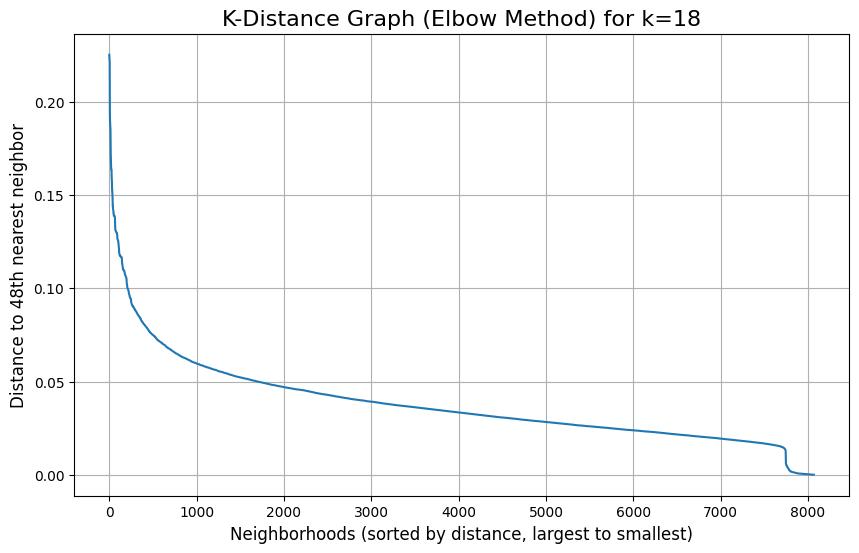

In [ ]:
# k is 18 based on the min_samples we chose
k = 18
X_features = norm_df.drop("Street_Name", axis=1).values

# Fit the algorithm on our data
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_features)

# Calculate distances
distances, indices = neighbors_fit.kneighbors(X_features)

# Extract the distance to the 18th neighbor ( most distant neighbor of the 18)
k_distances = distances[:, k-1]

# FLIP THE GRAPH: Sort the distances in descending order using [::-1]
k_distances_sorted_desc = np.sort(k_distances)[::-1]

# Plot the flipped K-distance graph
plt.figure(figsize=(10, 6))

plt.plot(k_distances_sorted_desc, linestyle='solid') 

plt.title(f'K-Distance Graph (Elbow Method) for k={k}', fontsize=16)
plt.xlabel('Neighborhoods (sorted by distance, largest to smallest)', fontsize=12)
plt.ylabel('Distance to 48th nearest neighbor', fontsize=12)
plt.grid(True)
plt.show()

We can see that between the elbow is between 0.05~ to 0.1. 

Let's run a for loop on this range of eps values to see which one gets us the better resoults.

In [13]:
# Let's test eps values from 0.02 up to 0.1 in increments of 0.01
for eps_value in np.arange(0.02, 0.1, 0.01):
    
    # Run DBSCAN with the current eps and our locked-in min_samples of 14
    db = DBSCAN(eps=eps_value, min_samples = 18).fit(norm_df.drop("Street_Name", axis=1))
    labels = db.labels_
    
    # Calculate clusters and noise
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # Only print results if it found more than 1 cluster
    if n_clusters_ > 1:
        print(f"eps={eps_value:.2f} | Clusters: {n_clusters_} | Noise Points: {n_noise_} -> {(n_noise_/8070)*100:.2f} %") # 245 is the amount of samples

eps=0.02 | Clusters: 9 | Noise Points: 5865 -> 72.68 %
eps=0.03 | Clusters: 8 | Noise Points: 3453 -> 42.79 %
eps=0.04 | Clusters: 8 | Noise Points: 1729 -> 21.43 %
eps=0.05 | Clusters: 4 | Noise Points: 861 -> 10.67 %
eps=0.06 | Clusters: 3 | Noise Points: 430 -> 5.33 %
eps=0.07 | Clusters: 2 | Noise Points: 253 -> 3.14 %
eps=0.08 | Clusters: 3 | Noise Points: 144 -> 1.78 %


We can see that the first optimal eps values for which we get a low amount of noise is for eps=0.05 with 6 clusters.

Let's choose those hyperparameters.

In [14]:
# Running DBSCAN on the parameters we found
db_final = DBSCAN(eps=0.05, min_samples = 18).fit(norm_df.drop("Street_Name",axis = 1))
labels = db_final.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# Attaching the cluster lablels to the data pre pca and normalization
norm_df["Cluster"] = db_final.labels_

print("Number of clusters: %d" % n_clusters_)
print("Number of noise points: %d" % n_noise_)

Number of clusters: 4
Number of noise points: 861


# Showing the clusters on the map

In [15]:
output(labels)

The labels: 0       0
1       0
2       0
3       0
4       0
       ..
8063    0
8064    0
8065    0
8066    0
8067    0
Length: 8068, dtype: int64
Value Counts:
  0    7113
-1     861
 3      56
 1      20
 2      18
Name: count, dtype: int64


Results are still not the best but slightly better than pre NMF clustering...

In [ ]:
# ============================================================
# STEP 1 — Filter streets to those in our data
# ============================================================

streets_to_plot = streets_projected[
    streets_projected['full_street_name'].isin(norm_df['Street_Name'])
][['full_street_name', 'geometry']].copy()

streets_to_plot = streets_to_plot.dissolve(by='full_street_name').reset_index()

# ============================================================
# STEP 2 — Merge cluster info
# ============================================================

streets_to_plot = streets_to_plot.merge(
    norm_df[['Street_Name', 'Cluster']],
    left_on='full_street_name',
    right_on='Street_Name',
    how='left'
)

streets_to_plot['Cluster'] = 'Cluster ' + streets_to_plot['Cluster'].astype(str)

# ============================================================
# STEP 3 — Reproject to 4326
# ============================================================

streets_to_plot = streets_to_plot.to_crs(epsg=4326)

print(f"Rendering {len(streets_to_plot):,} streets across {streets_to_plot['Cluster'].nunique()} clusters...")

# ============================================================
# STEP 4 — Build NYC outline from nyc_map (zip code polygons)
# ============================================================

boroughs = nyc_map[['geometry']].copy()  
boroughs['region'] = 'NYC'
boroughs = boroughs.dissolve(by='region').reset_index()  # merge all zips into one outline
boroughs = boroughs.to_crs(epsg=4326)

# ============================================================
# STEP 5 — Kepler.gl config
# ============================================================

kepler_config = {
    'version': 'v1',
    'config': {
        'visState': {
            'layers': [
                {
                    'type': 'geojson',
                    'config': {
                        'dataId': 'NYC Boroughs',
                        'label': 'NYC Boroughs',
                        'isVisible': True,
                        'visConfig': {
                            'opacity':       0.0,    # no fill, outline only
                            'strokeOpacity': 0.9,
                            'thickness':     1.5,
                            'stroked':       True,
                            'filled':        False,
                            'strokeColor':   [255, 255, 255],
                        },
                    },
                },
                {
                    'type': 'geojson',
                    'config': {
                        'dataId': 'NYC Streets by Cluster',
                        'label': 'NYC Streets by Cluster',
                        'isVisible': True,
                        'visConfig': {
                            'opacity':        0.85,
                            'strokeOpacity':  0.8,
                            'thickness':      0.5,
                            'stroked':        True,
                            'filled':         True,
                            'enable3d':       False,
                            'colorRange': {
                                'name':     'ColorBrewer Set1-9',
                                'type':     'qualitative',
                                'category': 'ColorBrewer',
                                'colors':   [
                                    '#e41a1c','#377eb8','#4daf4a',
                                    '#984ea3','#ff7f00','#ffff33',
                                    '#a65628','#f781bf','#999999'
                                ]
                            },
                        },
                    },
                    'visualChannels': {
                        'colorField': {
                            'name': 'Cluster',
                            'type': 'string'
                        },
                        'colorScale': 'ordinal',
                    }
                },
            ]
        },
        'mapState': {
            'latitude':  40.73,
            'longitude': -73.93,
            'zoom':      10
        },
        'mapStyle': {
            'styleType': 'dark',
            'visibleLayerGroups': {
                'label':    True,
                'road':     True,
                'border':   True,
                'building': False,
                'water':    True,
                'land':     True,
            }
        }
    }
}

# ============================================================
# STEP 6 — Render
# ============================================================

kepler_map = KeplerGl(height=750, config=kepler_config)

# Outline added first so it renders underneath
kepler_map.add_data(
    data=boroughs[['region', 'geometry']],
    name='NYC Boroughs'
)

kepler_map.add_data(
    data=streets_to_plot[['full_street_name', 'Cluster', 'geometry']],
    name='NYC Streets by Cluster'
)

kepler_map